In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from tqdm.auto import tqdm
import os
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [3]:
class ATTENTION(nn.Module):
    def __init__(self, hidden_dim):
        super(ATTENTION, self).__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)
    
    def forward(self, hidden, encoder_outputs):
        h = hidden[0]
        forward = h[-2, :, :]
        backward = h[-1, :, :]
        last_hidden = torch.cat([forward, backward], dim=1)
        last_hidden = last_hidden.unsqueeze(1)
        
        score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(last_hidden)))
        attention_weights = torch.softmax(score, dim=1)
        context = torch.sum(attention_weights * encoder_outputs, dim=1)
        
        return context

In [4]:
import torch
import torch.nn as nn
import numpy as np
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence


class LSTMENCODERDECODER(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, num_layers=1, dropout=0.3, pad_idx=0, use_attention=True, use_vae=False):
        super(LSTMENCODERDECODER, self).__init__()
        
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.pad_idx = pad_idx
        self.use_attention = use_attention
        self.use_vae = use_vae
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len=5000)
        
        self.encoder = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        if use_attention:
            self.attention = ATTENTION(hidden_dim * 2)
        
        if use_vae:
            self.fc_mu = nn.Linear(hidden_dim * 2, hidden_dim * 2)
            self.fc_logvar = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        
        self.bridge = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        
        self.decoder = nn.LSTM(
            embed_dim, hidden_dim * 2, num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        
        self.init_weights()

    def init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                if param.dim() >= 2:
                    if 'lstm' in name:
                        # Better LSTM init
                        if 'weight_ih' in name:
                            nn.init.xavier_uniform_(param)
                        elif 'weight_hh' in name:
                            nn.init.orthogonal_(param)
                    else:
                        nn.init.xavier_uniform_(param)
                else:
                    # For LayerNorm or 1D weights
                    nn.init.ones_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0.0)

    def forward(self, x, lengths=None, teacher_forcing_ratio=0.5):
        batch_size, seq_len = x.shape
        
        encoder_outputs, encoder_hidden = self.encode(x, lengths)
        
        if self.use_attention:
            context = self.attention(encoder_hidden, encoder_outputs)
        else:
            forward_hidden = encoder_hidden[0][-2, :, :]
            backward_hidden = encoder_hidden[0][-1, :, :]
            context = torch.cat([forward_hidden, backward_hidden], dim=1)
        
        kl_loss = 0
        if self.use_vae:
            mu = self.fc_mu(context)
            logvar = self.fc_logvar(context)
            context = self.reparameterize(mu, logvar)
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        
        context = self.bridge(context)
        context = torch.relu(context)
        decoder_hidden = self.init_decoder_hidden(context)
        
        outputs = []
        decoder_input = x[:, 0].unsqueeze(1)
        
        for t in range(1, seq_len):
            embedded = self.dropout(self.embedding(decoder_input))
            decoder_output, decoder_hidden = self.decoder(embedded, decoder_hidden)
            decoder_output = self.layer_norm(decoder_output)
            logits = self.fc_out(decoder_output)
            outputs.append(logits)
            
            if np.random.random() < teacher_forcing_ratio:
                decoder_input = x[:, t].unsqueeze(1)
            else:
                decoder_input = logits.argmax(dim=-1)
        
        outputs = torch.cat(outputs, dim=1)
        return outputs, kl_loss

    def encode(self, x, lengths=None):
        embedded = self.dropout(self.embedding(x))
        embedded = self.pos_encoding(embedded)
        
        if lengths is not None:
            packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
            output, hidden = self.encoder(packed)
            output, _ = pad_packed_sequence(output, batch_first=True)
        else:
            output, hidden = self.encoder(embedded)
        
        return output, hidden

    def get_query_vector(self, x, lengths=None):
        with torch.no_grad():
            encoder_outputs, encoder_hidden = self.encode(x, lengths)
            
            if self.use_attention:
                query_vec = self.attention(encoder_hidden, encoder_outputs)
            else:
                forward = encoder_hidden[0][-2, :, :]
                backward = encoder_hidden[0][-1, :, :]
                query_vec = torch.cat([forward, backward], dim=1)
            
            if self.use_vae:
                query_vec = self.fc_mu(query_vec)
            
            return query_vec

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def init_decoder_hidden(self, context):
        hidden = context.unsqueeze(0).repeat(self.num_layers, 1, 1)
        cell = torch.zeros_like(hidden)
        return (hidden, cell)

In [5]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [6]:
class MetricsTracker:
    def __init__(self):
        self.metrics = {'train_loss': [], 'val_loss': [], 'learning_rates': [], 'epoch_times': []}
    
    def update(self, **kwargs):
        for key, value in kwargs.items():
            if key in self.metrics:
                self.metrics[key].append(value)
    
    def plot(self, save_path='training_metrics.png'):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        axes[0, 0].plot(self.metrics['train_loss'], label='Train Loss', linewidth=2)
        if self.metrics['val_loss']:
            axes[0, 0].plot(self.metrics['val_loss'], label='Val Loss', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training & Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].plot(self.metrics['learning_rates'], color='orange', linewidth=2)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Learning Rate')
        axes[0, 1].set_title('Learning Rate Schedule')
        axes[0, 1].set_yscale('log')
        axes[0, 1].grid(True, alpha=0.3)
        
        if self.metrics['epoch_times']:
            axes[1, 0].bar(range(len(self.metrics['epoch_times'])), self.metrics['epoch_times'], color='green', alpha=0.7)
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Time (seconds)')
            axes[1, 0].set_title('Time per Epoch')
            axes[1, 0].grid(True, alpha=0.3, axis='y')
        
        axes[1, 1].hist(self.metrics['train_loss'], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[1, 1].set_xlabel('Loss Value')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Loss Distribution')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Metrics plot saved to {save_path}")

In [7]:
print("="*70)
print(" QUERY2VEC - LSTM AUTOENCODER")
print("="*70)

data = torch.load('/kaggle/input/datasets/balasiva2007/encoded-data/final_encoded_data.pt')
encoded_queries = data['encoded_queries']
token2id = data['token2id']
vocab_size = len(token2id)
pad_idx = token2id.get('<PAD>', 0)

print(f"\nDataset Statistics:")
print(f"Vocabulary size: {vocab_size:,}")
print(f"Total queries: {len(encoded_queries):,}")

 QUERY2VEC - LSTM AUTOENCODER

Dataset Statistics:
Vocabulary size: 7,184
Total queries: 95,836


In [8]:
X_list = []
lengths = []

for q in encoded_queries:
    if len(q) > 1:
        X_list.append(torch.tensor(q, dtype=torch.long))
        lengths.append(len(q))

X_padded = pad_sequence(X_list, batch_first=True, padding_value=pad_idx)
lengths_tensor = torch.tensor(lengths, dtype=torch.long)

print(f"Prepared sequences: {len(X_list):,}")
print(f"Max sequence length: {X_padded.shape[1]}")
print(f"Average length: {np.mean(lengths):.1f}")

Prepared sequences: 95,836
Max sequence length: 864
Average length: 108.2


In [9]:
train_size = int(0.9 * len(X_list))
val_size = len(X_list) - train_size

indices = torch.randperm(len(X_list))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = TensorDataset(X_padded[train_indices], lengths_tensor[train_indices])
val_dataset = TensorDataset(X_padded[val_indices], lengths_tensor[val_indices])

batch_size = 96
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"\nData Split:")
print(f"Training samples: {train_size:,}")
print(f"Validation samples: {val_size:,}")


Data Split:
Training samples: 86,252
Validation samples: 9,584


In [10]:

embed_dim = 64
hidden_dim = 64
num_layers = 2
dropout = 0.3
use_attention = True
use_vae = False

learning_rate = 0.001
weight_decay = 1e-5
epochs = 10
grad_clip = 1.0
teacher_forcing_ratio = 0.5

model = LSTMENCODERDECODER(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    pad_idx=pad_idx,
    use_attention=use_attention,
    use_vae=use_vae
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Configuration:")
print(f"  Embedding dim: {embed_dim}")
print(f"  Hidden dim: {hidden_dim}")
print(f"  Num layers: {num_layers}")
print(f"  Dropout: {dropout}")
print(f"  Use attention: {use_attention}")
print(f"  Use VAE: {use_vae}")

print(f"\nTraining Configuration:")
print(f"  Learning rate: {learning_rate}")
print(f"  Weight decay: {weight_decay}")
print(f"  Epochs: {epochs}")
print(f"  Grad clip: {grad_clip}")
print(f"  Teacher forcing ratio: {teacher_forcing_ratio}")

print(f"\nModel Parameters:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


Model Configuration:
  Embedding dim: 64
  Hidden dim: 64
  Num layers: 2
  Dropout: 0.3
  Use attention: True
  Use VAE: False

Training Configuration:
  Learning rate: 0.001
  Weight decay: 1e-05
  Epochs: 10
  Grad clip: 1.0
  Teacher forcing ratio: 0.5

Model Parameters:
  Total parameters: 1,833,745
  Trainable parameters: 1,833,745


In [11]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
print(f"\nDevice: {device}")

early_stopping = EarlyStopping(patience=10, verbose=True)
metrics_tracker = MetricsTracker()
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)


Device: cuda


In [12]:
def train_epoch(model, loader, criterion, optimizer, device, grad_clip, teacher_forcing_ratio, use_vae):
    model.train()
    total_loss = 0
    
    progress_bar = tqdm(loader, desc='Training', leave=False)
    for batch_X, batch_lengths in progress_bar:
        batch_X = batch_X.to(device)
        batch_lengths = batch_lengths.to(device)
        
        optimizer.zero_grad()
        logits, kl_loss = model(batch_X, batch_lengths, teacher_forcing_ratio)
        
        logits = logits.reshape(-1, model.vocab_size)
        targets = batch_X[:, 1:].reshape(-1)
        
        recon_loss = criterion(logits, targets)
        loss = recon_loss + (0.01 * kl_loss if use_vae else 0)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    return total_loss / len(loader)

def validate(model, loader, criterion, device, use_vae):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch_X, batch_lengths in loader:
            batch_X = batch_X.to(device)
            batch_lengths = batch_lengths.to(device)
            
            logits, kl_loss = model(batch_X, batch_lengths, teacher_forcing_ratio=0)
            
            logits = logits.reshape(-1, model.vocab_size)
            targets = batch_X[:, 1:].reshape(-1)
            
            recon_loss = criterion(logits, targets)
            loss = recon_loss + (0.01 * kl_loss if use_vae else 0)
            
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [13]:
checkpoint_dir = "/kaggle/working/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

print("\n" + "="*70)
print("TRAINING START")
print("="*70 + "\n")

best_val_loss = float('inf')
epochs = 5

for epoch in range(epochs):
    epoch_start = datetime.now()
    
    train_loss = train_epoch(
        model, train_loader, criterion, optimizer,
        device, grad_clip, teacher_forcing_ratio, use_vae
    )
    
    val_loss = validate(model, val_loader, criterion, device, use_vae)
    
    scheduler.step()
    
    epoch_time = (datetime.now() - epoch_start).total_seconds()
    
    metrics_tracker.update(
        train_loss=train_loss,
        val_loss=val_loss,
        learning_rates=optimizer.param_groups[0]['lr'],
        epoch_times=epoch_time
    )
    
    print(f"Epoch {epoch+1:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
          f"Time: {epoch_time:.1f}s")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        
        best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
        
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': val_loss
        }, best_model_path)
        
        print(f" Best model saved (Val Loss: {val_loss:.4f})")
    
    checkpoint_path = os.path.join(
        checkpoint_dir, f'checkpoint_epoch{epoch+1}.pth'
    )
    
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss
    }, checkpoint_path)
    
    print(f" Checkpoint saved: epoch {epoch+1}")
    
    early_stopping(val_loss)
    
    if early_stopping.early_stop:
        print("\n Early stopping triggered!")
        break

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print(f"Best validation loss: {best_val_loss:.4f}")
print("="*70)


TRAINING START



Training:   0%|          | 0/899 [00:00<?, ?it/s]

Epoch 01/5 | Train Loss: 2.7212 | Val Loss: 5.6803 | LR: 0.000976 | Time: 1524.1s
 Best model saved (Val Loss: 5.6803)
 Checkpoint saved: epoch 1


Training:   0%|          | 0/899 [00:00<?, ?it/s]

Epoch 02/5 | Train Loss: 1.5839 | Val Loss: 5.7999 | LR: 0.000905 | Time: 1524.2s
 Checkpoint saved: epoch 2
EarlyStopping counter: 1/10


...

Epoch 03/5 | Train Loss: 1.3851 | Val Loss: 5.9097 | LR: 0.000794 | Time: 1544.4s
 Checkpoint saved: epoch 3
EarlyStopping counter: 2/10


Training:   0%|          | 0/899 [00:00<?, ?it/s]

Epoch 04/5 | Train Loss: 1.2923 | Val Loss: 5.7193 | LR: 0.000655 | Time: 1553.0s
 Checkpoint saved: epoch 4
EarlyStopping counter: 3/10


Training:   0%|          | 0/899 [00:00<?, ?it/s]

Epoch 05/5 | Train Loss: 1.2294 | Val Loss: 5.8554 | LR: 0.000500 | Time: 1548.3s
 Checkpoint saved: epoch 5
EarlyStopping counter: 4/10

TRAINING COMPLETE!
Best validation loss: 5.6803


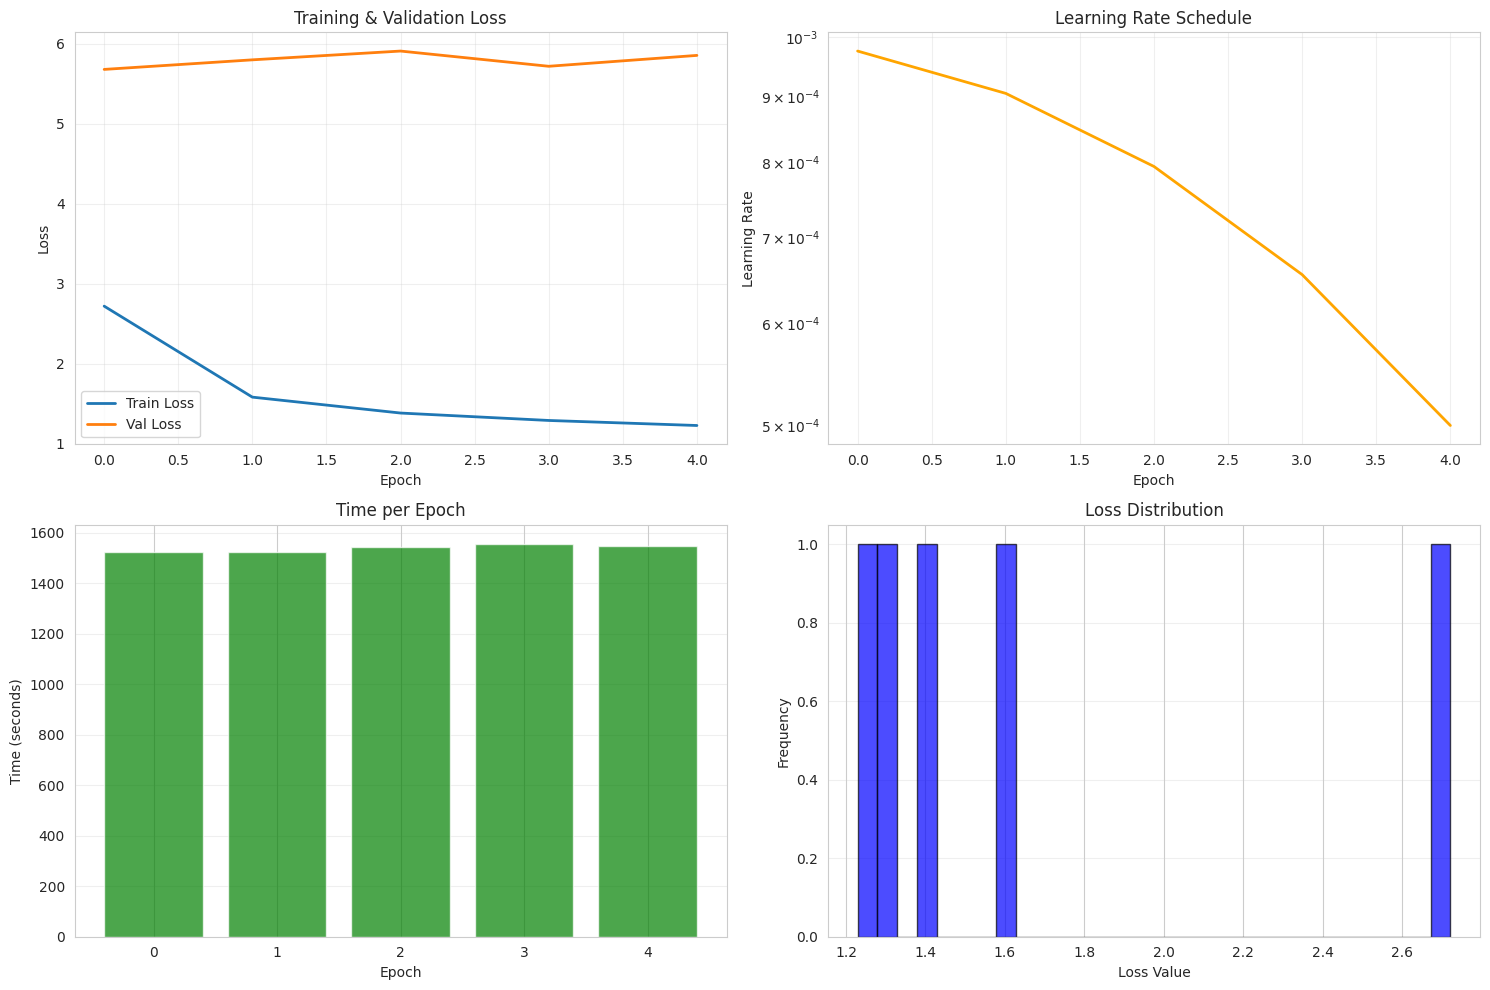

Metrics plot saved to training_metrics.png

 Configuration saved to 'training_config.json'


In [14]:
metrics_tracker.plot('training_metrics.png')

training_config = {
    'model': {
        'embed_dim': embed_dim,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'dropout': dropout,
        'use_attention': use_attention,
        'use_vae': use_vae
    },
    'training': {
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'epochs': epochs,
        'grad_clip': grad_clip,
        'teacher_forcing_ratio': teacher_forcing_ratio,
        'batch_size': batch_size
    },
    'results': {
        'best_val_loss': float(best_val_loss),
    }
}

with open(os.path.join(checkpoint_dir, 'training_config.json'), 'w') as f:
    json.dump(training_config, f, indent=4)

print("\n Configuration saved to 'training_config.json'")

In [15]:
final_model_path = "/kaggle/working/final_model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}, final_model_path)

print(f"Model saved at: {final_model_path}")

Model saved at: /kaggle/working/final_model.pth


In [16]:
print("\n" + "="*70)
print("EXTRACTING QUERY EMBEDDINGS")
print("="*70)

checkpoint = torch.load(os.path.join(checkpoint_dir, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_embeddings = []
all_lengths = []

with torch.no_grad():
    for batch_X, batch_lengths in tqdm(DataLoader(train_dataset, batch_size=64, shuffle=False), desc='Extracting embeddings'):
        batch_X = batch_X.to(device)
        batch_lengths = batch_lengths.to(device)
        
        query_vecs = model.get_query_vector(batch_X, batch_lengths)
        all_embeddings.append(query_vecs.cpu())
        all_lengths.extend(batch_lengths.cpu().numpy())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()

print(f"\n Extracted {all_embeddings.shape[0]:,} embeddings")
print(f" Embedding dimension: {all_embeddings.shape[1]}")


EXTRACTING QUERY EMBEDDINGS


Extracting embeddings:   0%|          | 0/1348 [00:00<?, ?it/s]


 Extracted 86,252 embeddings
 Embedding dimension: 128
